# Notebook 9: Research Results and Ablation Study

**Objective:** Produce all paper-ready results including:
- Ablation study (with/without graph structure, with/without class balancing)
- Temporal vs random split comparison
- Combined ROC / PR curves
- Final comparison table for publication

In [1]:
import sys
sys.path.append('../src')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from graph_builder import load_graph
from models import GCN, GraphSAGE, GAT
from train import train_model
from evaluate import evaluate_model, build_comparison_table
from utils import set_seed, get_device, save_model, load_model

set_seed(42)
device = get_device()
sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
data = load_graph('../data/processed')

## 1. Ablation 1: With vs Without Class Weights

In [3]:
ablation_results = {}

for use_cw, label in [(True, 'GCN + Class Weights'), (False, 'GCN - Class Weights')]:
    m = GCN(data.num_features, 64, 2)
    m, _ = train_model(m, data, epochs=150, use_class_weights=use_cw, device=device)
    res = evaluate_model(m, data, data.test_mask, device)
    from sklearn.metrics import f1_score, precision_score, recall_score
    ablation_results[label] = {
        'f1'     : f1_score(res['y_true'], res['y_pred'], zero_division=0),
        'recall' : recall_score(res['y_true'], res['y_pred'], zero_division=0),
        'pr_auc' : res['pr_auc'],
        'roc_auc': res['roc_auc'],
    }

pd.DataFrame(ablation_results).T.round(4)

Epoch  20 | Train Loss: 0.4417 | Val Loss: 0.4192


Epoch  40 | Train Loss: 0.3673 | Val Loss: 0.3777


Epoch  60 | Train Loss: 0.3286 | Val Loss: 0.3505


Epoch  80 | Train Loss: 0.3093 | Val Loss: 0.3343


Epoch 100 | Train Loss: 0.2937 | Val Loss: 0.3232


...

Epoch 100 | Train Loss: 0.1864 | Val Loss: 0.1758


Epoch 120 | Train Loss: 0.1778 | Val Loss: 0.1705


Epoch 140 | Train Loss: 0.1718 | Val Loss: 0.1663


              precision    recall  f1-score   support

       Licit       0.96      0.99      0.98      8404
     Illicit       0.89      0.62      0.73       909

    accuracy                           0.96      9313
   macro avg       0.92      0.80      0.85      9313
weighted avg       0.95      0.96      0.95      9313

ROC-AUC : 0.9408
PR-AUC  : 0.7939


,f1,recall,pr_auc,roc_auc
GCN + Class Weights,0.6317,0.8867,0.7956,0.9612
GCN - Class Weights,0.7294,0.6183,0.7939,0.9408


## 2. Ablation 2: Model Depth (2-layer vs 3-layer GCN)

In [4]:
from models import DeepGCN
from sklearn.metrics import f1_score, recall_score

for ModelClass, label in [(GCN, 'GCN 2-Layer'), (DeepGCN, 'GCN 3-Layer')]:
    m = ModelClass(data.num_features, 64, 2)
    m, _ = train_model(m, data, epochs=150, use_class_weights=True, device=device)
    res = evaluate_model(m, data, data.test_mask, device)
    ablation_results[label] = {
        'f1'     : f1_score(res['y_true'], res['y_pred'], zero_division=0),
        'recall' : recall_score(res['y_true'], res['y_pred'], zero_division=0),
        'pr_auc' : res['pr_auc'],
        'roc_auc': res['roc_auc'],
    }

pd.DataFrame(ablation_results).T.round(4)

Epoch  20 | Train Loss: 0.4574 | Val Loss: 0.4439


Epoch  40 | Train Loss: 0.3941 | Val Loss: 0.3988


Epoch  60 | Train Loss: 0.3474 | Val Loss: 0.3657


Epoch  80 | Train Loss: 0.3283 | Val Loss: 0.3450


Epoch 100 | Train Loss: 0.3068 | Val Loss: 0.3308


...

Epoch 100 | Train Loss: 0.3163 | Val Loss: 0.3263


Epoch 120 | Train Loss: 0.2950 | Val Loss: 0.3140


Epoch 140 | Train Loss: 0.2911 | Val Loss: 0.3044


              precision    recall  f1-score   support

       Licit       0.99      0.88      0.93      8404
     Illicit       0.44      0.90      0.60       909

    accuracy                           0.88      9313
   macro avg       0.72      0.89      0.76      9313
weighted avg       0.94      0.88      0.90      9313

ROC-AUC : 0.9579
PR-AUC  : 0.7813


,f1,recall,pr_auc,roc_auc
GCN + Class Weights,0.6317,0.8867,0.7956,0.9612
GCN - Class Weights,0.7294,0.6183,0.7939,0.9408
GCN 2-Layer,0.6077,0.8911,0.7794,0.9580
GCN 3-Layer,0.5952,0.9043,0.7813,0.9579


## 3. Temporal Split Experiment

The Elliptic dataset has 49 time steps. A temporal split trains on early steps and tests on later steps — more realistic than a random split.

In [5]:
from sklearn.metrics import f1_score, recall_score

# Reload raw features to get the time step (column 1)
try:
    features_raw = pd.read_csv('../data/raw/elliptic_txs_features.csv', header=None)
    time_steps   = features_raw.iloc[:, 1].values

    # Only use labeled nodes (same indices as data.x)
    n = data.num_nodes
    time_steps = time_steps[:n]

    cutoff = int(np.percentile(time_steps, 70))
    print(f'Temporal cutoff time step: {cutoff}')

    temporal_train_mask = torch.tensor(time_steps <= cutoff, dtype=torch.bool)
    temporal_test_mask  = torch.tensor(time_steps >  cutoff, dtype=torch.bool)

    data_t = data.clone()
    data_t.train_mask = temporal_train_mask
    data_t.val_mask   = temporal_train_mask
    data_t.test_mask  = temporal_test_mask

    m_temp = GCN(data.num_features, 64, 2)
    m_temp, _ = train_model(m_temp, data_t, epochs=150, use_class_weights=True, device=device)
    res_temp  = evaluate_model(m_temp, data_t, data_t.test_mask, device)
    print('\nTemporal split results:')
    print(f'  F1: {f1_score(res_temp["y_true"], res_temp["y_pred"], zero_division=0):.4f}')
    print(f'  PR-AUC: {res_temp["pr_auc"]:.4f}')
except FileNotFoundError:
    print('Raw data not found. Download the Elliptic dataset first.')

Temporal cutoff time step: 6


Epoch  20 | Train Loss: 0.4250 | Val Loss: 0.3761


Epoch  40 | Train Loss: 0.3578 | Val Loss: 0.3220


Epoch  60 | Train Loss: 0.3294 | Val Loss: 0.2935


Epoch  80 | Train Loss: 0.3031 | Val Loss: 0.2741


Epoch 100 | Train Loss: 0.2892 | Val Loss: 0.2590


Epoch 120 | Train Loss: 0.2791 | Val Loss: 0.2463


Epoch 140 | Train Loss: 0.2612 | Val Loss: 0.2355


              precision    recall  f1-score   support

       Licit       0.97      0.84      0.90     10087
     Illicit       0.19      0.64      0.30       608

    accuracy                           0.83     10695
   macro avg       0.58      0.74      0.60     10695
weighted avg       0.93      0.83      0.87     10695

ROC-AUC : 0.8312
PR-AUC  : 0.5185

Temporal split results:
  F1: 0.2982
  PR-AUC: 0.5185


## 4. Final Ablation Summary Table

In [6]:
df_ablation = pd.DataFrame(ablation_results).T.round(4)
print(df_ablation.to_string())
df_ablation.to_csv('../results/ablation_results.csv')

                         f1  recall  pr_auc  roc_auc
GCN + Class Weights  0.6317  0.8867  0.7956   0.9612
GCN - Class Weights  0.7294  0.6183  0.7939   0.9408
GCN 2-Layer          0.6077  0.8911  0.7794   0.9580
GCN 3-Layer          0.5952  0.9043  0.7813   0.9579


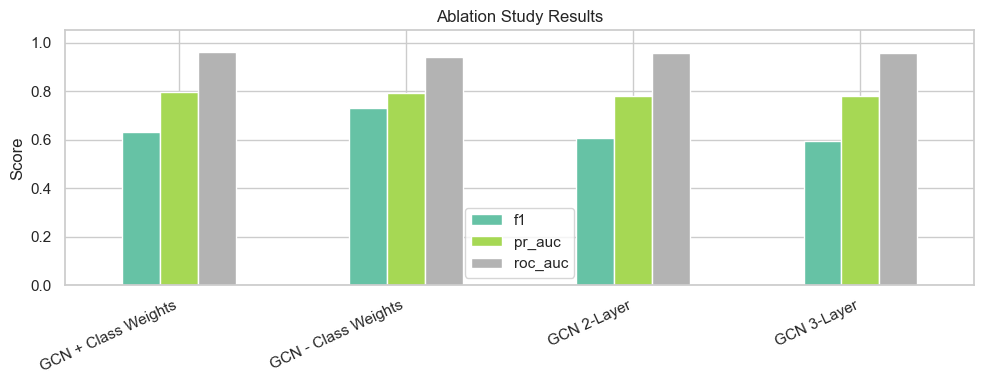

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
df_ablation[['f1','pr_auc','roc_auc']].plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Ablation Study Results')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/ablation_study.png', dpi=150)
plt.show()

## 5. Print Final Paper Table

In [8]:
try:
    df_final = pd.read_csv('../results/comparison_table.csv', index_col=0)
    print('=== FINAL MODEL COMPARISON TABLE (for paper) ===')
    print(df_final.to_markdown())
except FileNotFoundError:
    print('Run notebook 07 first to generate comparison_table.csv')

=== FINAL MODEL COMPARISON TABLE (for paper) ===
| Model               |   accuracy |   precision |   recall |     f1 |   roc_auc |   pr_auc |
|:--------------------|-----------:|------------:|---------:|-------:|----------:|---------:|
| Logistic Regression |     0.8783 |      0.4414 |   0.9285 | 0.5984 |    0.9649 |   0.7546 |
| Random Forest       |     0.9875 |      0.9962 |   0.8757 | 0.9321 |    0.9966 |   0.9817 |
| XGBoost             |     0.9928 |      0.993  |   0.9329 | 0.962  |    0.9974 |   0.9872 |
| LightGBM            |     0.9927 |      0.9873 |   0.9373 | 0.9616 |    0.9982 |   0.9895 |
| MLP                 |     0.9811 |      0.9379 |   0.8636 | 0.8992 |    0.9856 |   0.9408 |
| GCN                 |     0.9069 |      0.5132 |   0.8955 | 0.6525 |    0.9648 |   0.8098 |
| GraphSAGE           |     0.9358 |      0.6175 |   0.8988 | 0.7321 |    0.977  |   0.8995 |
| GAT                 |     0.8743 |      0.4342 |   0.9516 | 0.5963 |    0.9759 |   0.8681 |
